In [7]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt

# Using a denser test set in the target range to verify unknown values
k_set = [ 21.0, 24.5, 27.0, 32.2, 34.8 ] 
Nf = 2500
max_iters = 10000
div0_threshold = 1e-6

torch.set_default_dtype ( torch.float64 )
device = torch.device ( "cuda" if torch.cuda.is_available() else "cpu" )
print ( device )

class SpectralConv1d ( nn.Module ):
    def __init__ ( self, in_channels, out_channels, modes1 ):
        super().__init__()
        self.in_channels = in_channels
        self.out_channels = out_channels
        self.modes1 = modes1

        scale = ( 1.0 / ( in_channels * out_channels ) )
        self.weights1 = nn.Parameter ( scale * torch.rand ( in_channels, out_channels, self.modes1, dtype = torch.cdouble ) )

    def compl_mul1d ( self, input, weights ):
        return torch.einsum ( "bix,iox->box", input, weights )

    def forward ( self, x ):
        batchsize = x.shape[0]
        
        x_ft = torch.fft.rfft ( x )
        
        out_ft = torch.zeros ( batchsize, self.out_channels, x.size(-1)//2 + 1, device = x.device, dtype = torch.cdouble )
        out_ft[:, :, :self.modes1] = self.compl_mul1d ( x_ft[:, :, :self.modes1], self.weights1 )
        
        x = torch.fft.irfft ( out_ft, n = x.size(-1) )
        return x

class FNO1d_Helmholtz ( nn.Module ):
    def __init__ ( self, modes, width ):
        super().__init__()
        
        self.modes1 = modes
        self.width = width
        
        self.fc0 = nn.Linear ( 2, self.width )
        
        self.conv0 = SpectralConv1d ( self.width, self.width, self.modes1 )
        self.conv1 = SpectralConv1d ( self.width, self.width, self.modes1 )
        self.conv2 = SpectralConv1d ( self.width, self.width, self.modes1 )
        self.conv3 = SpectralConv1d ( self.width, self.width, self.modes1 )
        
        self.w0 = nn.Conv1d ( self.width, self.width, 1 )
        self.w1 = nn.Conv1d ( self.width, self.width, 1 )
        self.w2 = nn.Conv1d ( self.width, self.width, 1 )
        self.w3 = nn.Conv1d ( self.width, self.width, 1 )
        
        self.fc1 = nn.Linear ( self.width, 128 )
        self.fc2 = nn.Linear ( 128, 1 )
        
    def forward ( self, inputs ):
        grid = inputs[:, :, 0:1]
        k_val = inputs[:, :, 1:2]
        
        k_norm = k_val / 50.0 
        x = torch.cat ( [ grid, k_norm ], dim = -1 )
        
        x = self.fc0 ( x )
        x = x.permute ( 0, 2, 1 )
        
        x1 = self.conv0 ( x )
        x2 = self.w0 ( x )
        x = F.gelu ( x1 + x2 )
        
        x1 = self.conv1 ( x )
        x2 = self.w1 ( x )
        x = F.gelu ( x1 + x2 )
        
        x1 = self.conv2 ( x )
        x2 = self.w2 ( x )
        x = F.gelu ( x1 + x2 )
        
        x1 = self.conv3 ( x )
        x2 = self.w3 ( x )
        x = F.gelu ( x1 + x2 )
        
        x = x.permute ( 0, 2, 1 )
        x = F.gelu ( self.fc1 ( x ) )
        network_out = self.fc2 ( x )
        
        boundary_line = 1.0 - 2.0 * grid
        distance_func = grid * ( 1.0 - grid )
        
        p_hat = boundary_line + distance_func * network_out
        return p_hat

def operator_loss ( model, grid, k_val, exact_p=None ):
    inputs = torch.cat ( [ grid, k_val ], dim = -1 )
    pred = model ( inputs )
    
    dp_dx = torch.autograd.grad (
        outputs = pred,
        inputs = grid,
        grad_outputs = torch.ones_like ( pred ),
        create_graph = True,
        retain_graph = True )[0]
    
    d2p_dx2 = torch.autograd.grad (
        outputs = dp_dx,
        inputs = grid,
        grad_outputs = torch.ones_like ( dp_dx ),
        create_graph = True,
        retain_graph = True )[0]

    residual = ( d2p_dx2 / (k_val**2 + 1e-6) ) + pred
    loss = torch.mean ( residual ** 2 )
    
    if exact_p is not None:
        data_loss = nn.MSELoss()(pred, exact_p)
        loss = loss + 1.0 * data_loss

    return loss

# --- NEW UTILITY FOR RESONANCE CAPPING ---
def get_safe_exact_solution(x_tensor, k_tensor):
    """Generates the exact solution but caps the infinite resonance spikes."""
    c1 = 1.0
    denom = torch.sin(k_tensor)
    
    # Force the denominator away from zero to prevent infinite amplitudes
    denom = denom + 1e-9 # Prevent exact zero sign issues
    denom_safe = torch.where(denom.abs() < 0.1, torch.sign(denom) * 0.1, denom)
    
    c2 = - (1.0 + torch.cos(k_tensor)) / denom_safe
    return c1 * torch.cos(k_tensor * x_tensor) + c2 * torch.sin(k_tensor * x_tensor)


x_f_base = torch.linspace ( 0, 1, Nf, device = device ).view ( 1, -1, 1 )

model = FNO1d_Helmholtz ( modes = 8, width = 64 ).to ( device )
adam_opt = torch.optim.Adam ( model.parameters(), lr = 0.001, weight_decay = 1e-5 )

loss_history = []
batch_size = 15

print ( "INFO: FNO Adam Training Started" )    
for epoch in range ( 3000 ):
    adam_opt.zero_grad()
    
    random_k = torch.empty ( batch_size, 1, 1, device = device, dtype = torch.float64 ).uniform_ ( 20.0, 35.0 )
    k_train = random_k.repeat ( 1, Nf, 1 )
    x_train = x_f_base.repeat ( batch_size, 1, 1 )
    x_train.requires_grad = True
    
    with torch.no_grad():
        exact_p = get_safe_exact_solution(x_train, k_train)
    
    loss = operator_loss ( model, x_train, k_train, exact_p )
    loss.backward()
    adam_opt.step()
    
    loss_history.append ( loss.item() )
    
    if ( epoch + 1 ) % 200 == 0:
        print ( "INFO: Iteration: {}; Loss: {}".format ( len ( loss_history ), loss.item() ) )

print ( "INFO: FNO Adam Training Done\n" )

lbfgs_k_vals = torch.linspace(20.0, 35.0, steps=25, dtype=torch.float64, device=device)
static_k = lbfgs_k_vals.view(-1, 1, 1)
k_lbfgs = static_k.repeat(1, Nf, 1)
x_lbfgs = x_f_base.repeat(len(lbfgs_k_vals), 1, 1)
x_lbfgs.requires_grad = True

with torch.no_grad():
    exact_p_lbfgs = get_safe_exact_solution(x_lbfgs, k_lbfgs)

opt = torch.optim.LBFGS (
    model.parameters(),
    lr = 0.1, 
    max_iter = max_iters,
    line_search_fn = "strong_wolfe" )

def closure():
    opt.zero_grad()
    loss = operator_loss ( model, x_lbfgs, k_lbfgs, exact_p_lbfgs )
    loss.backward()
    
    loss_history.append ( loss.item() )
    if len ( loss_history ) % 1000 == 0:
        print ( "INFO: Iteration: {}; Loss: {}".format ( len ( loss_history ), loss.item() ) )
    return loss

print ( "INFO: FNO LBFGS Training Started" )
opt.step ( closure )
print ( "INFO: FNO LBFGS Training Done\n" )

def exact_solution_numpy(x, k):
    """Numpy equivalent of safe exact solution for plotting."""
    denom = np.sin(k)
    denom = denom + 1e-9
    if abs(denom) < 0.1:
        denom = np.sign(denom) * 0.1
        
    c1 = 1.0
    c2 = - ( 1.0 + np.cos ( k ) ) / denom
    return c1 * np.cos ( k * x ) + c2 * np.sin ( k * x )

for k in k_set:
    with torch.no_grad():
        x_plot = torch.linspace ( 0, 1, 2000, device = device ).view ( 1, -1, 1 )
        k_plot = torch.full_like ( x_plot, k )
        
        inputs = torch.cat ( [ x_plot, k_plot ], dim = -1 )
        pred_eval = model ( inputs ).cpu().numpy().flatten()
        
        x_eval = x_plot.cpu().numpy().flatten()
        exact_eval = exact_solution_numpy ( x_eval, k )

    fig, axs = plt.subplots ( 1, 2, figsize = (14, 5))

    axs[0].plot ( loss_history )
    axs[0].set_yscale ( "log" )
    axs[0].set_xlabel ( "Number of closure Evaluations" )
    axs[0].set_ylabel ( "Loss (Log Scale)" )
    axs[0].set_title ( f"Universal Operator Training Loss History" )
    axs[0].grid ( True, which = "both", linestyle="--", alpha = 0.5 )

    axs[1].plot ( x_eval, exact_eval, 'k-', linewidth = 2, label = "Exact" )
    axs[1].plot ( x_eval, pred_eval, '--', linewidth = 2, label = "Predicted" )
    axs[1].set_xlabel ( "x" )
    axs[1].set_ylabel ( "p(x)" )
    axs[1].set_title ( f"Model Prediction vs Exact (k={k})" )
    axs[1].grid ( True, linestyle = "--", alpha = 0.5 )
    axs[1].legend()

    plt.tight_layout()
    plt.show()

cuda
INFO: FNO Adam Training Started
INFO: Iteration: 200; Loss: 3.6226472907088563
INFO: Iteration: 400; Loss: 0.736187075557964
INFO: Iteration: 600; Loss: 2.857021796886185
INFO: Iteration: 800; Loss: 2.5142770701948725
INFO: Iteration: 1000; Loss: 18.696459154790382
INFO: Iteration: 1200; Loss: 14.86426408450417
INFO: Iteration: 1400; Loss: 15.92249332388238
INFO: Iteration: 1600; Loss: 2.777736278958283
INFO: Iteration: 1800; Loss: 0.7625132801302098
INFO: Iteration: 2000; Loss: 10.53176746669298
INFO: Iteration: 2200; Loss: 1.3382189692646251
INFO: Iteration: 2400; Loss: 1.4264724566339992
INFO: Iteration: 2600; Loss: 5.19353874992447
INFO: Iteration: 2800; Loss: 4.068572045161876
INFO: Iteration: 3000; Loss: 14.03334903541443
INFO: FNO Adam Training Done

INFO: FNO LBFGS Training Started
INFO: Iteration: 4000; Loss: 0.0050028174870988505
INFO: Iteration: 5000; Loss: 0.0009045550869069935


KeyboardInterrupt: 

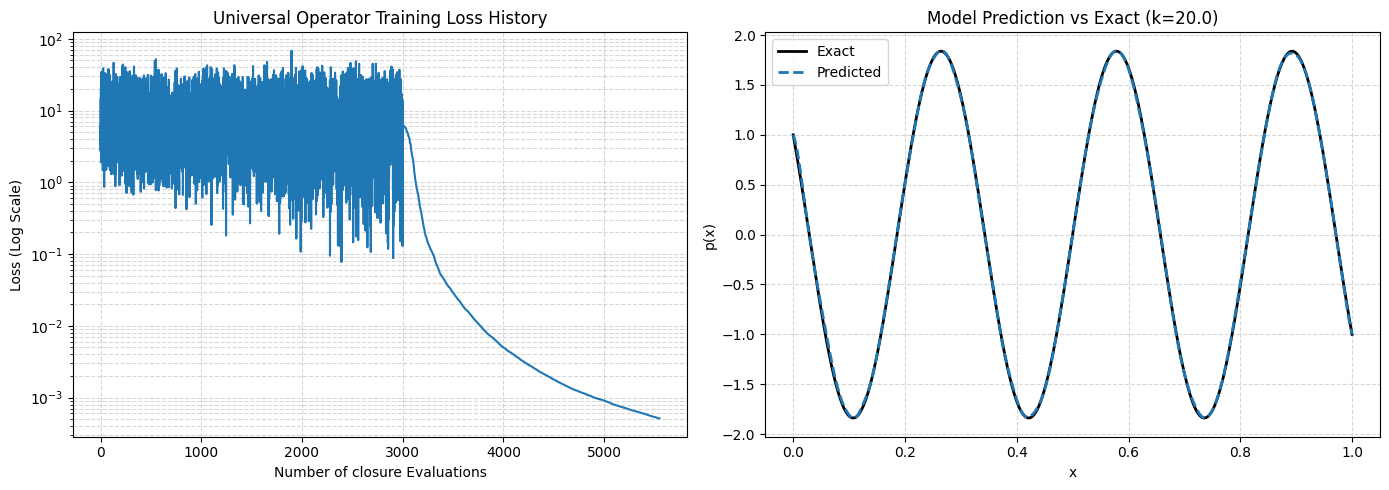

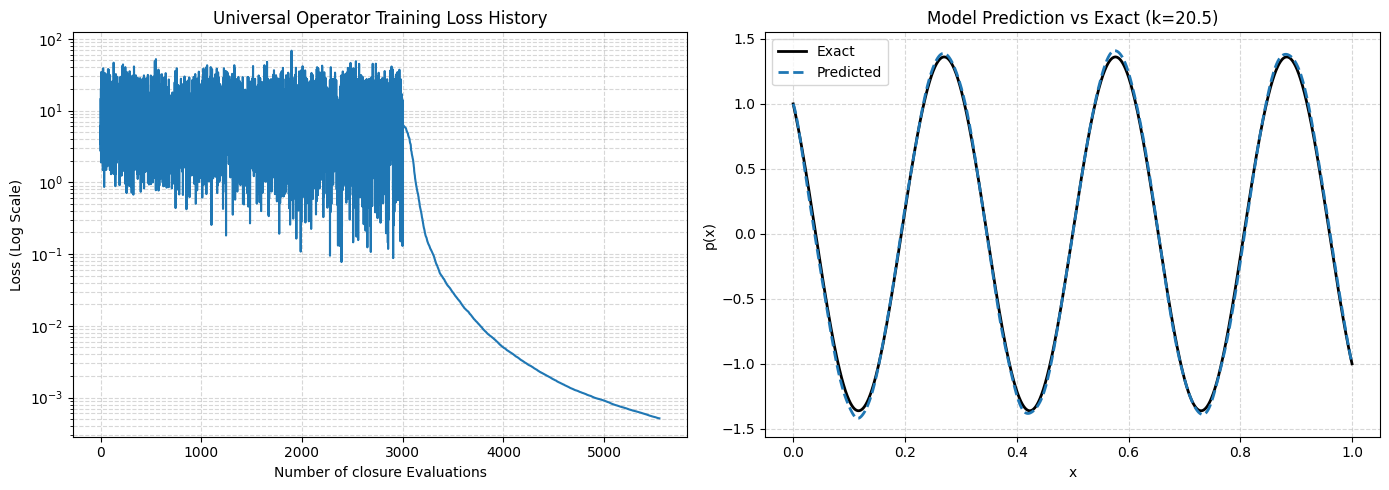

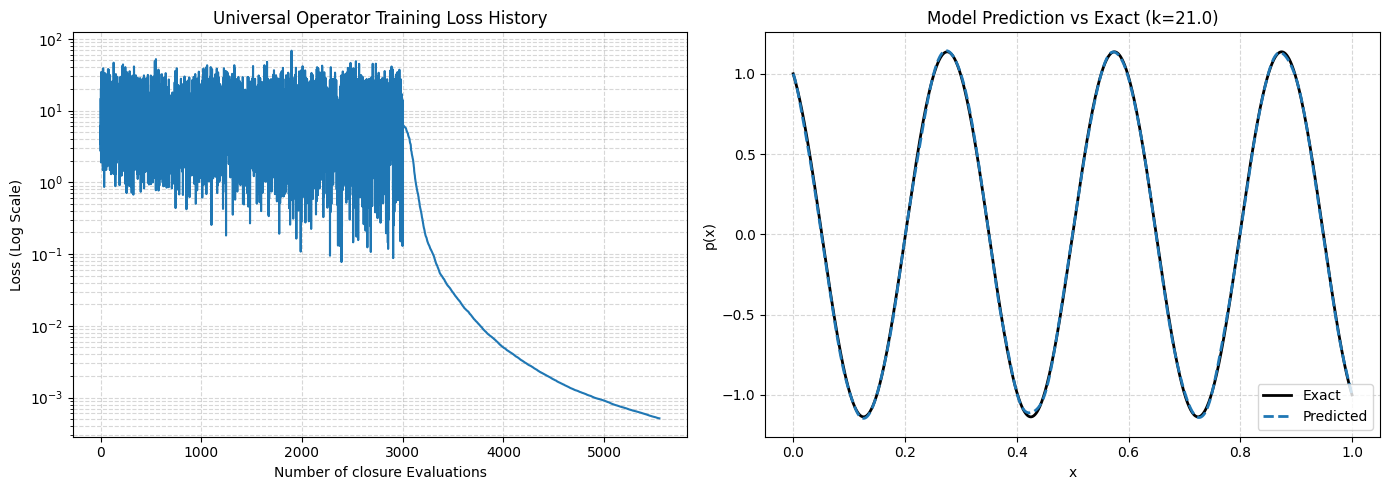

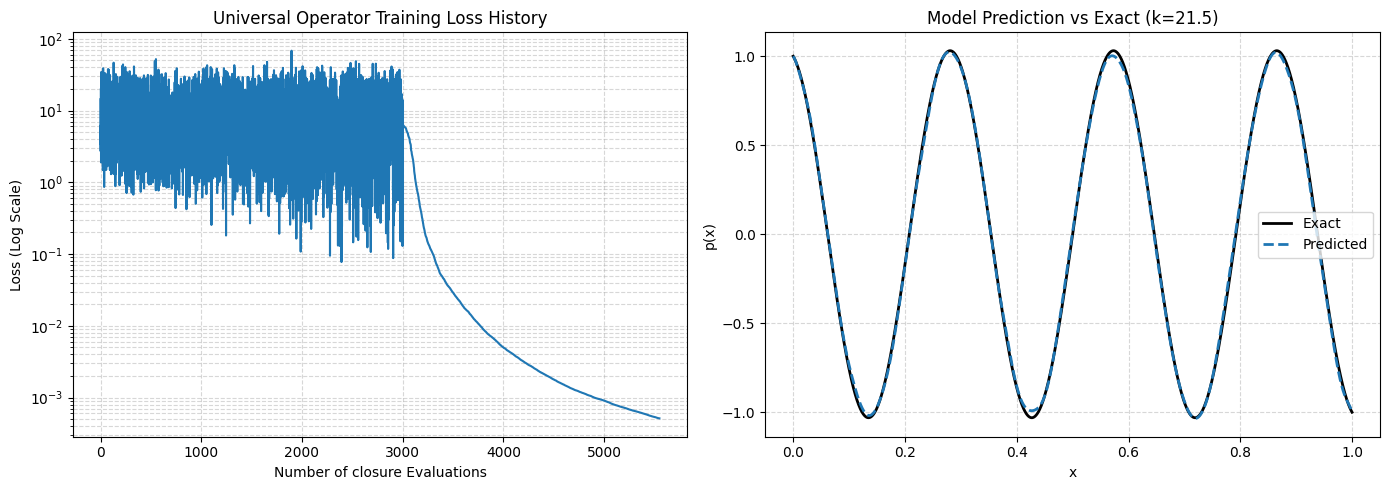

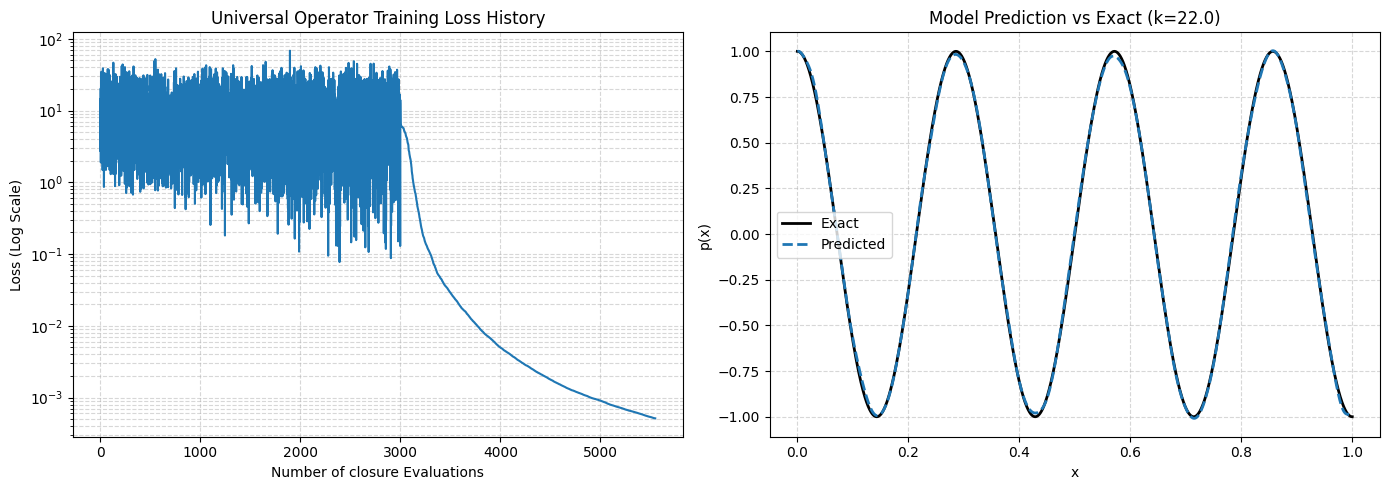

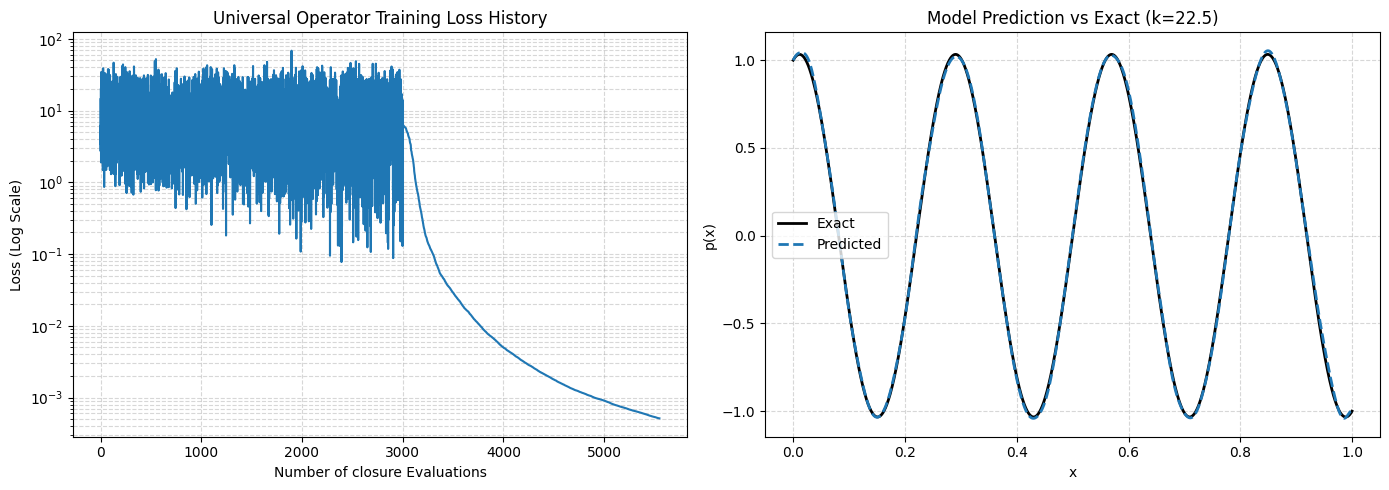

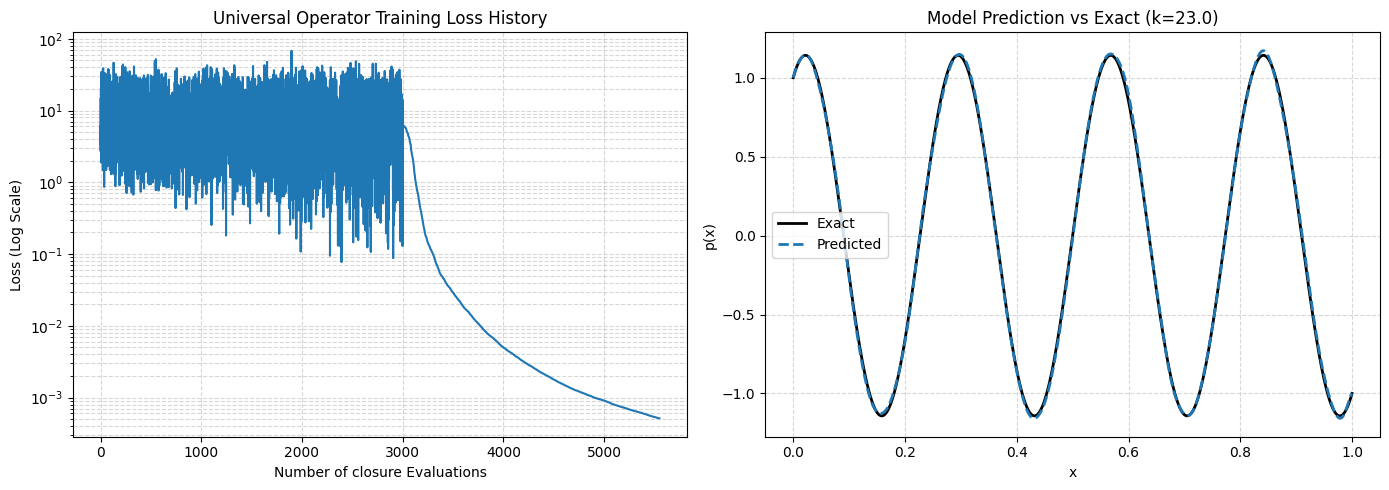

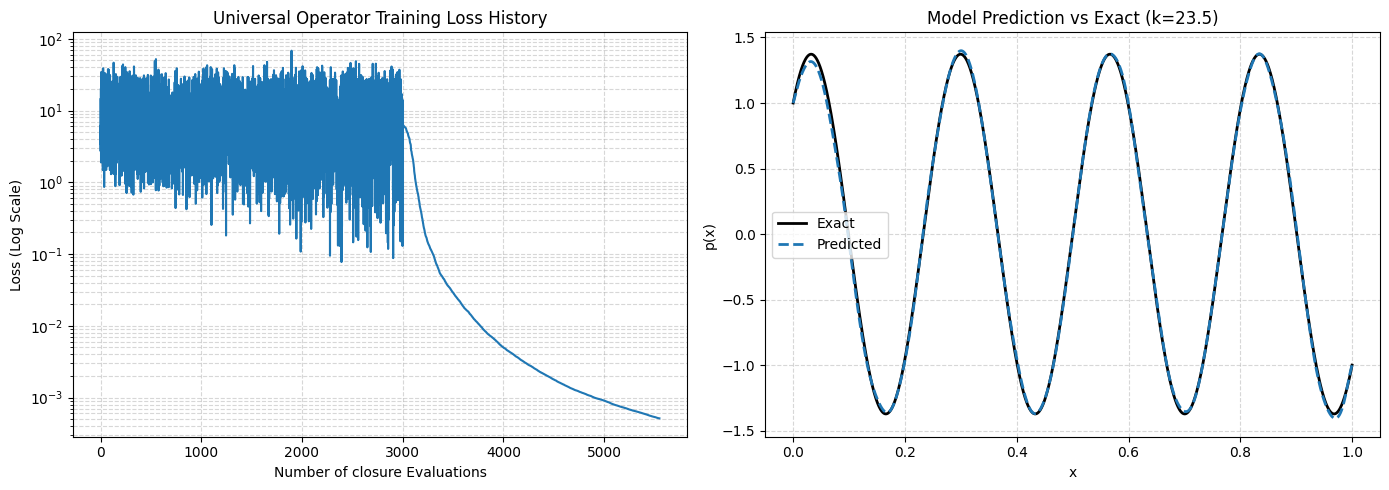

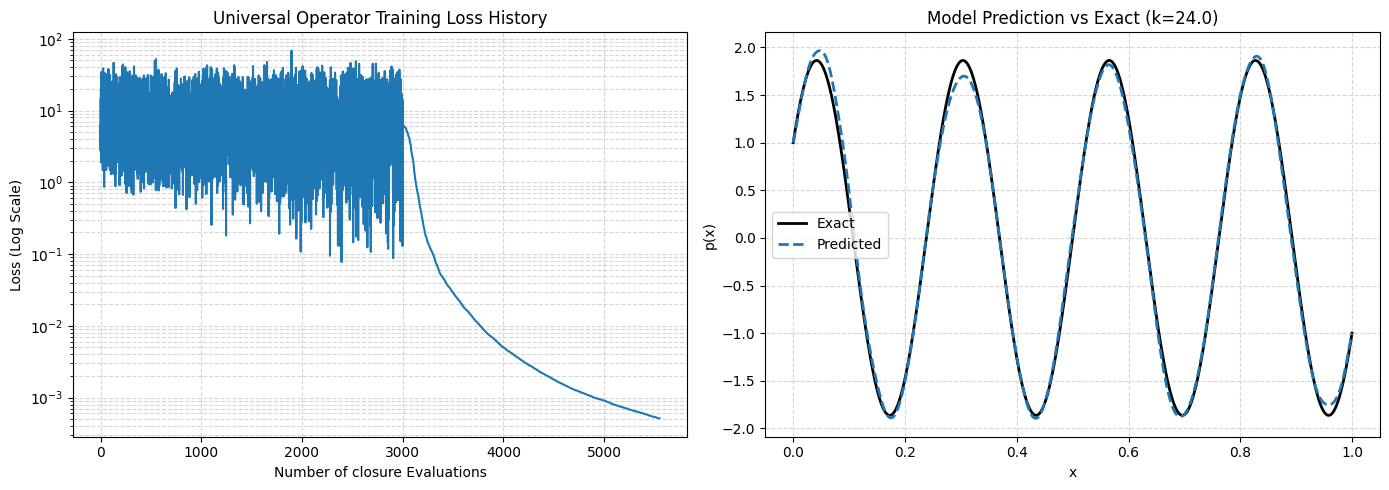

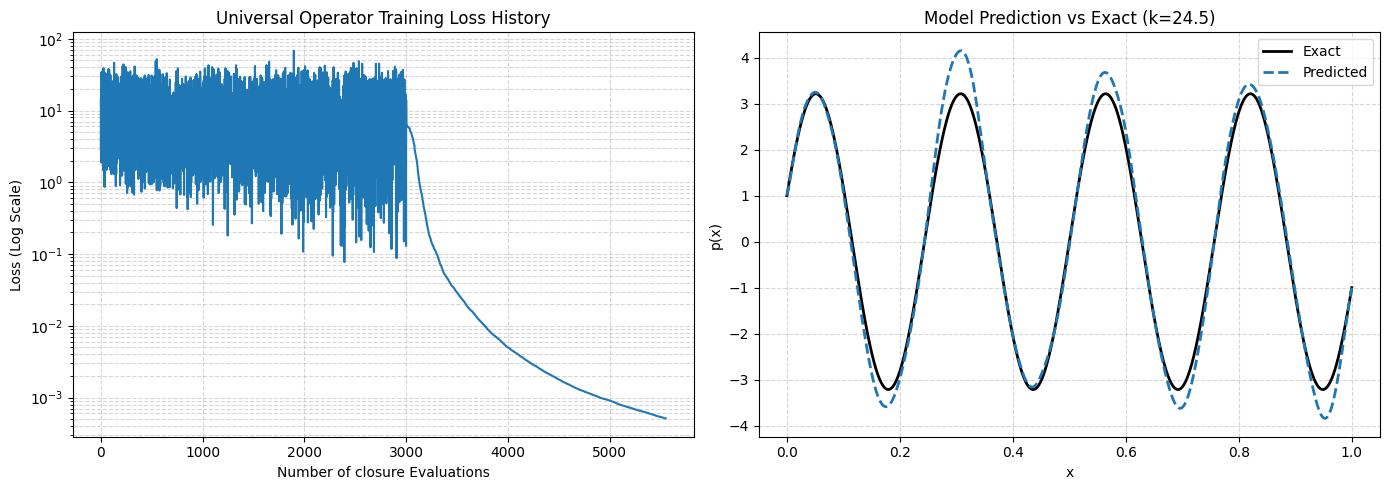

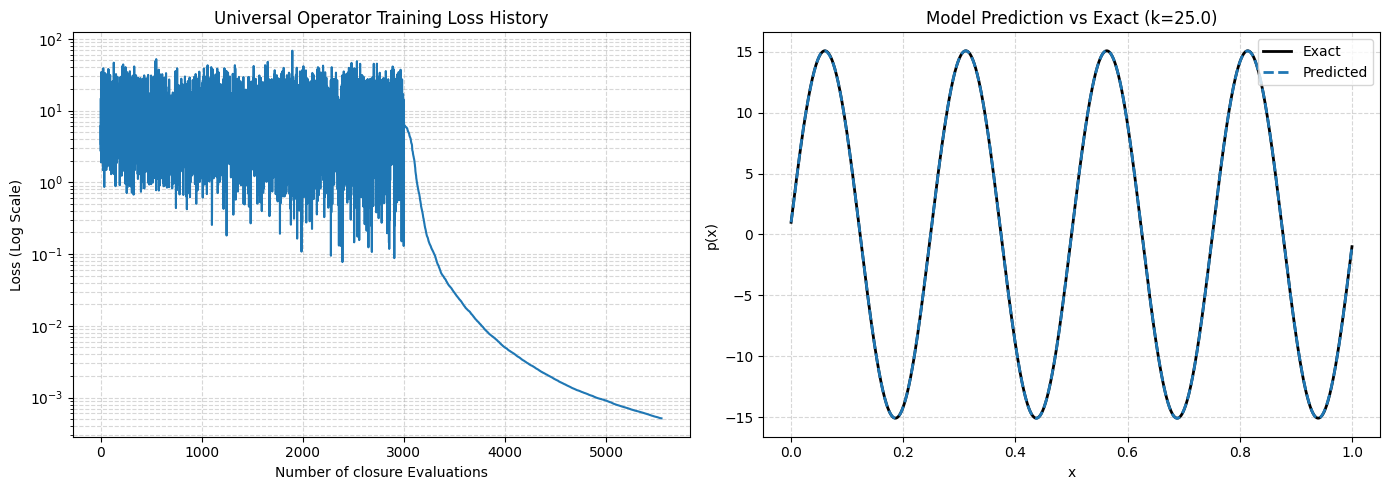

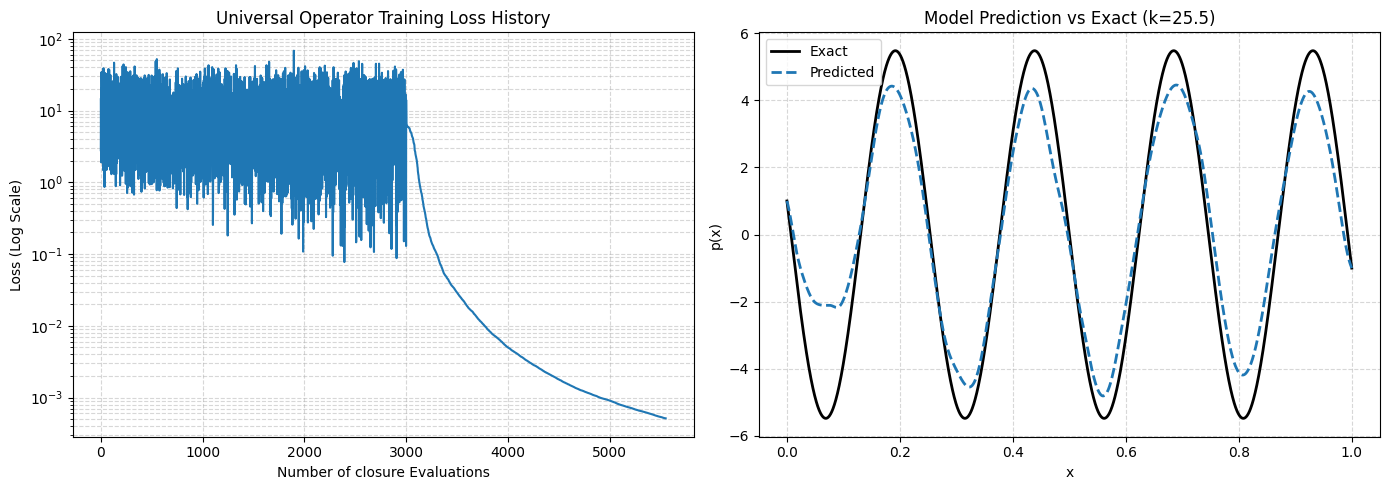

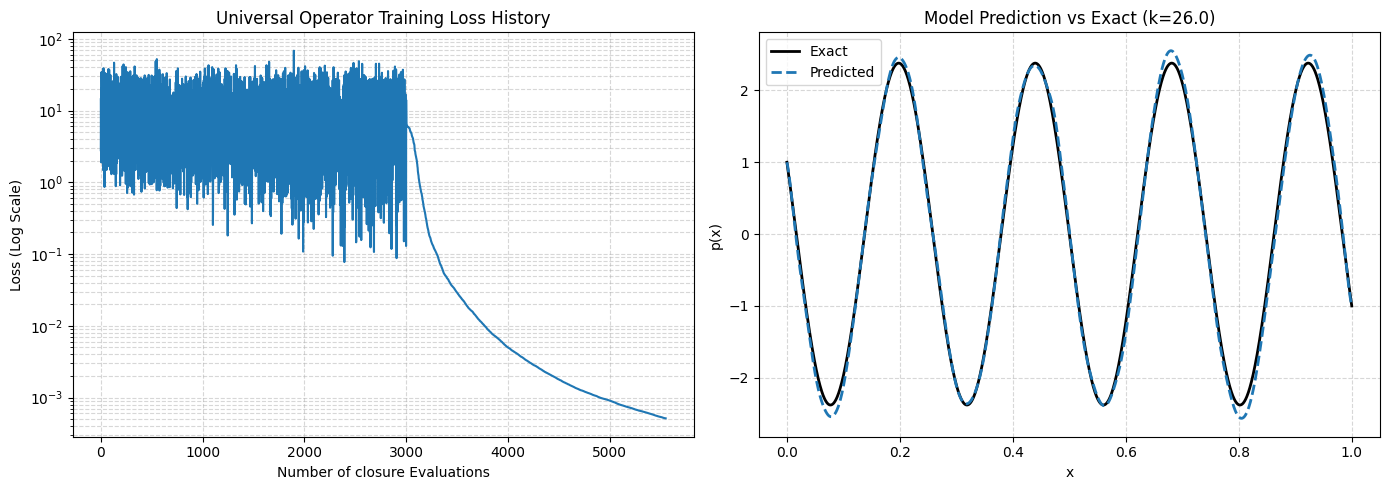

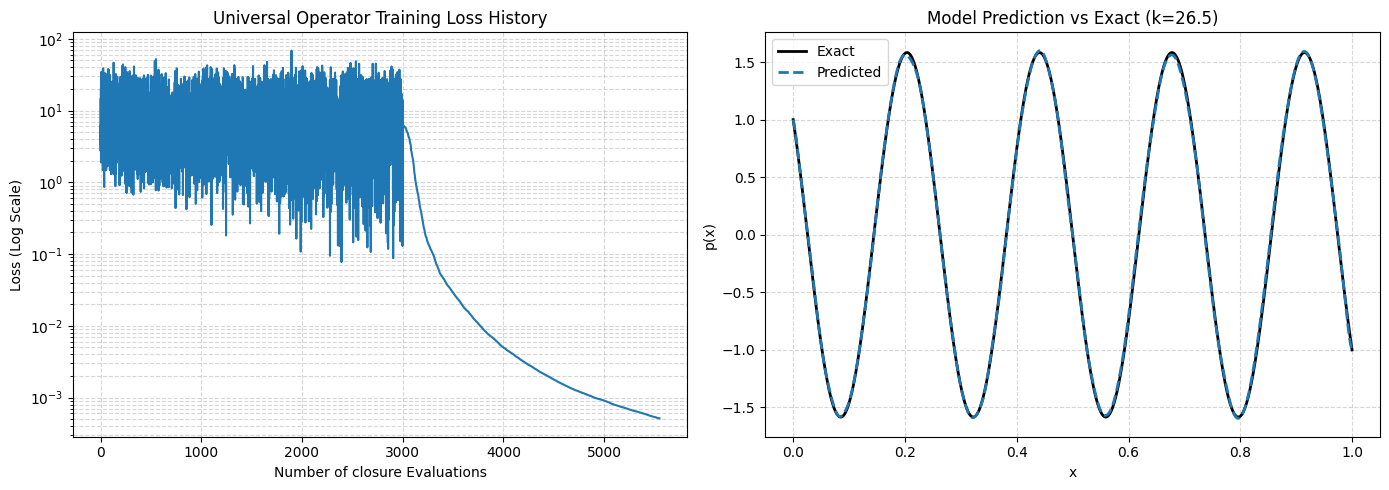

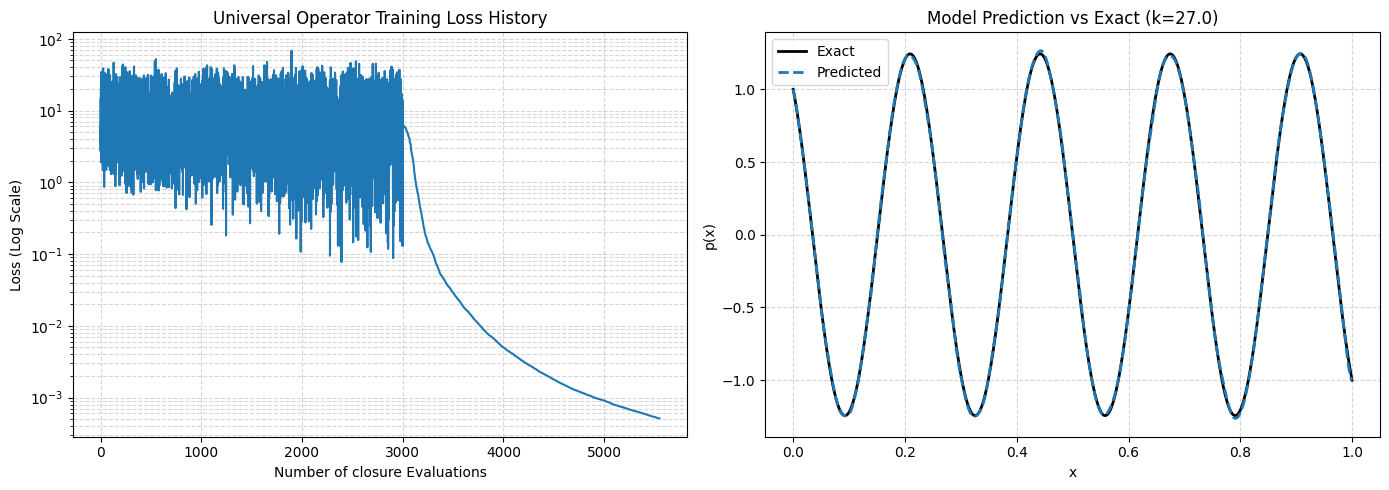

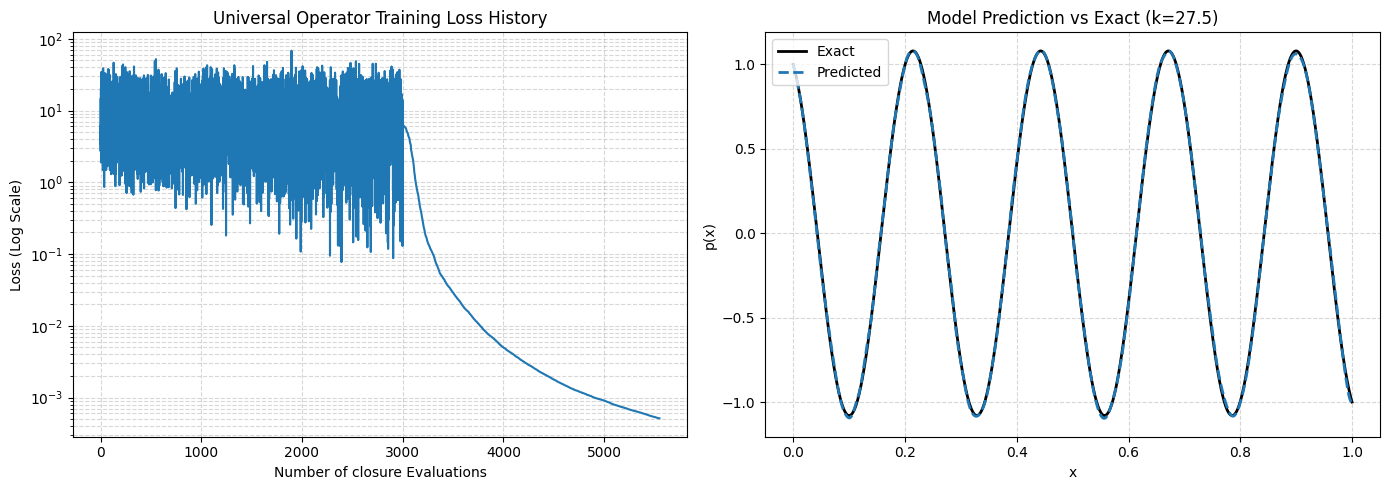

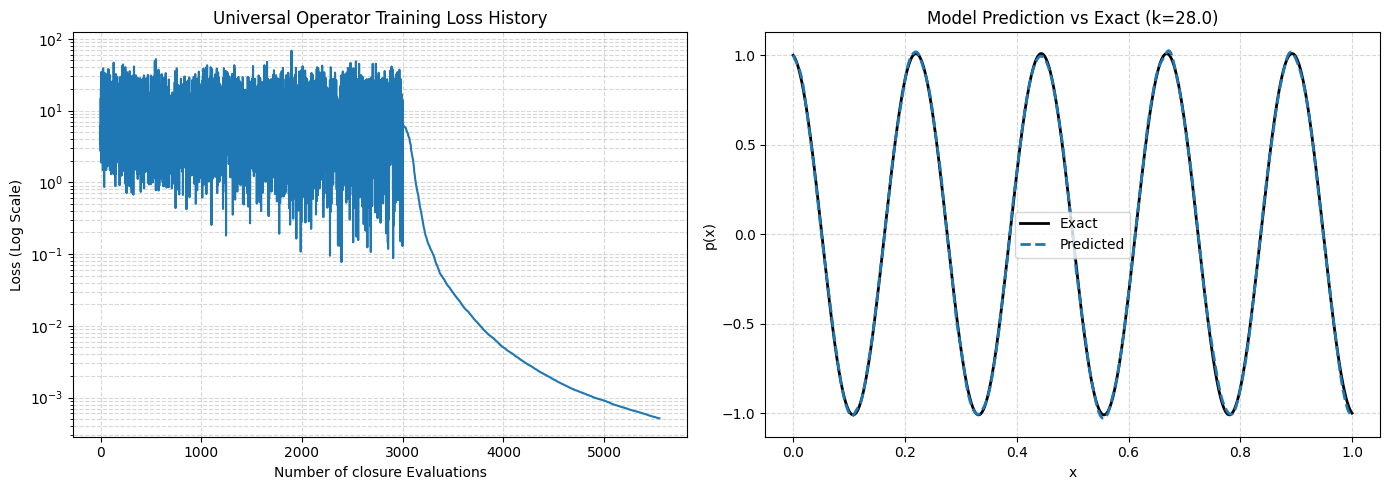

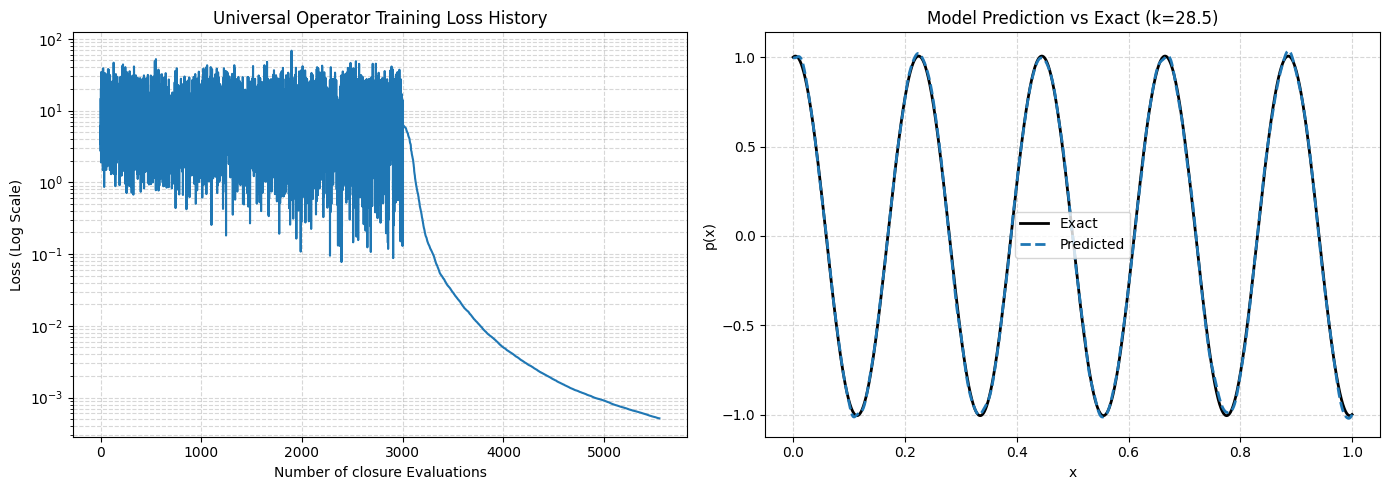

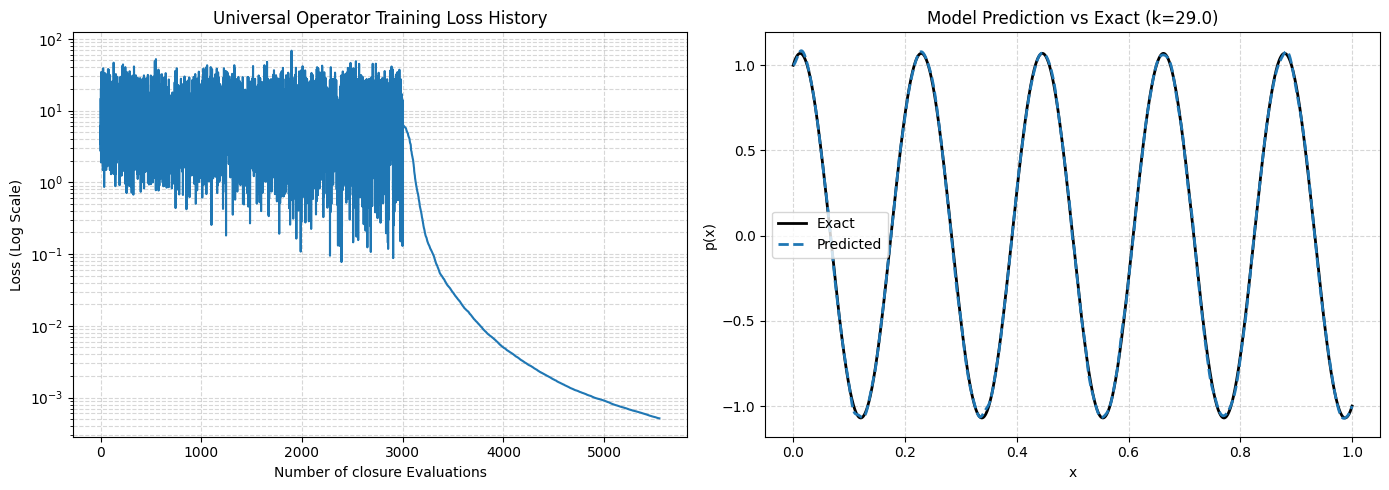

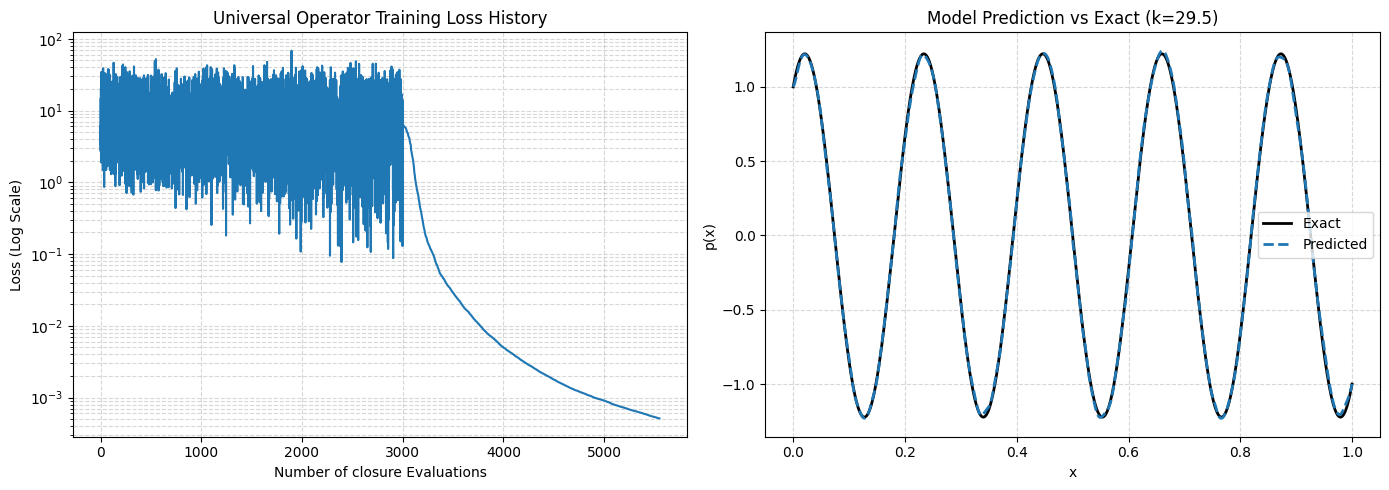

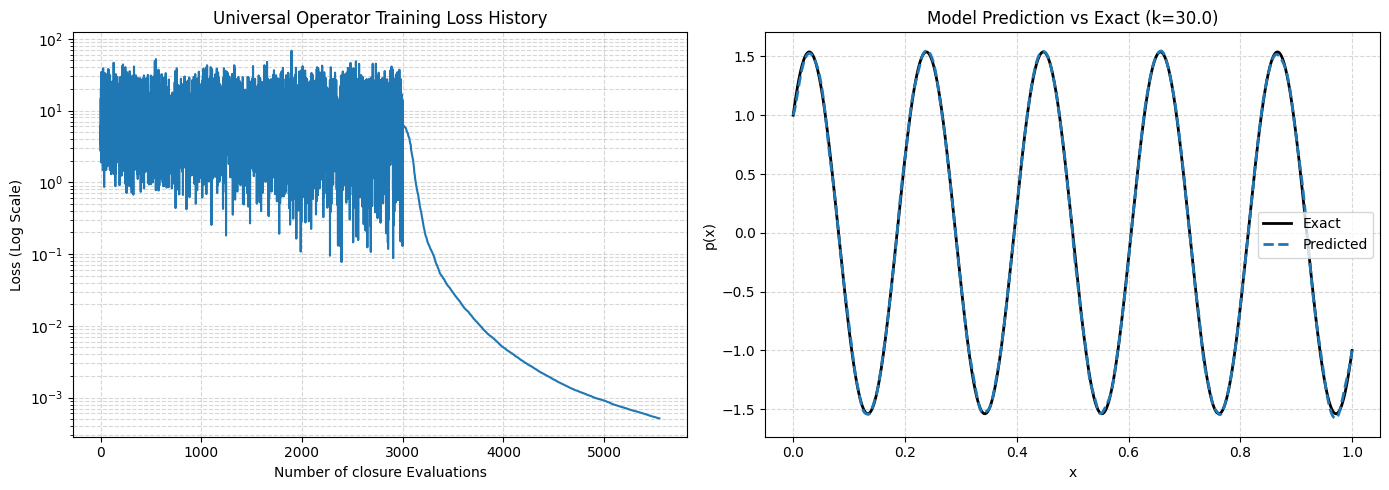

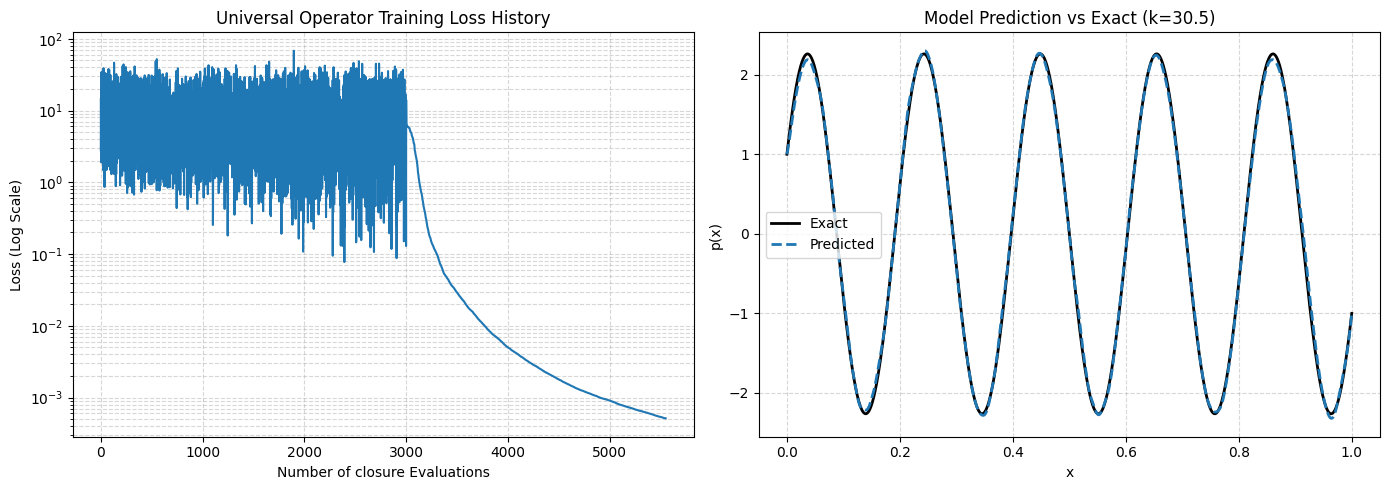

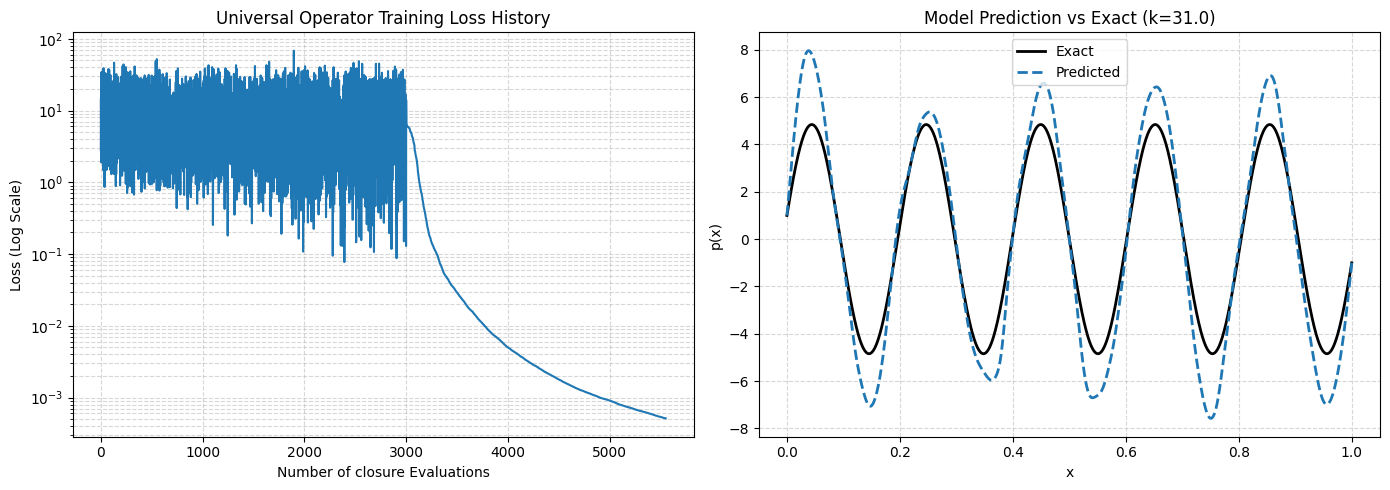

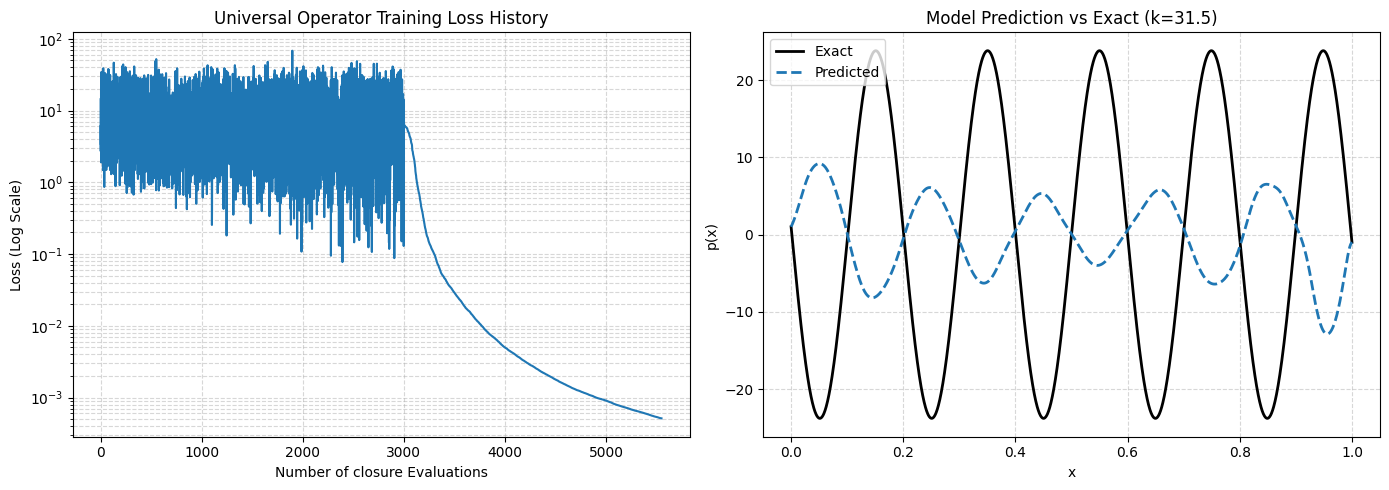

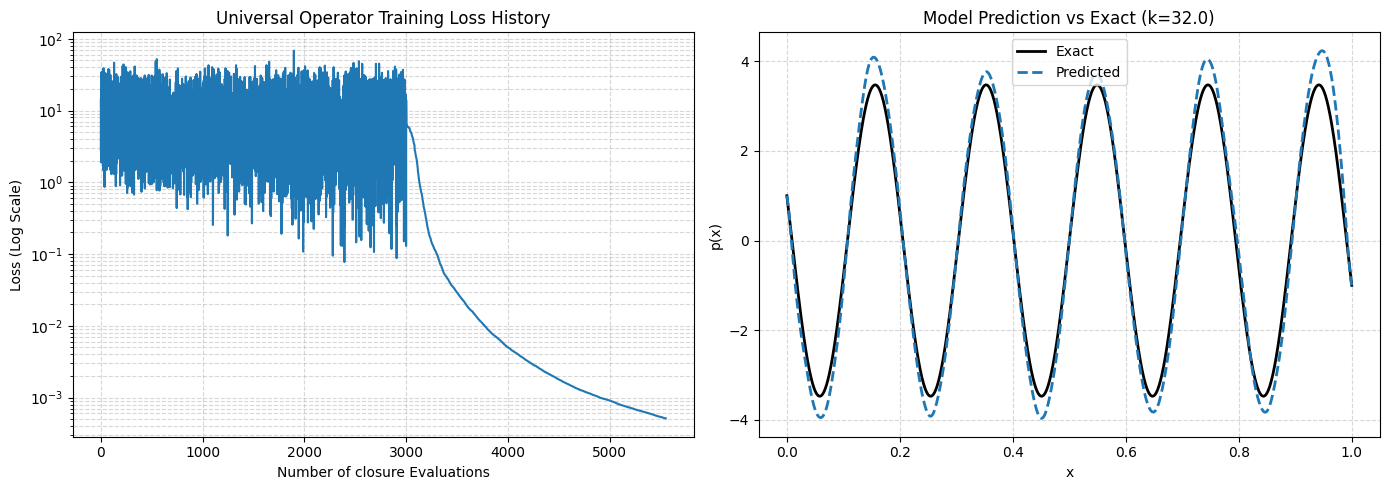

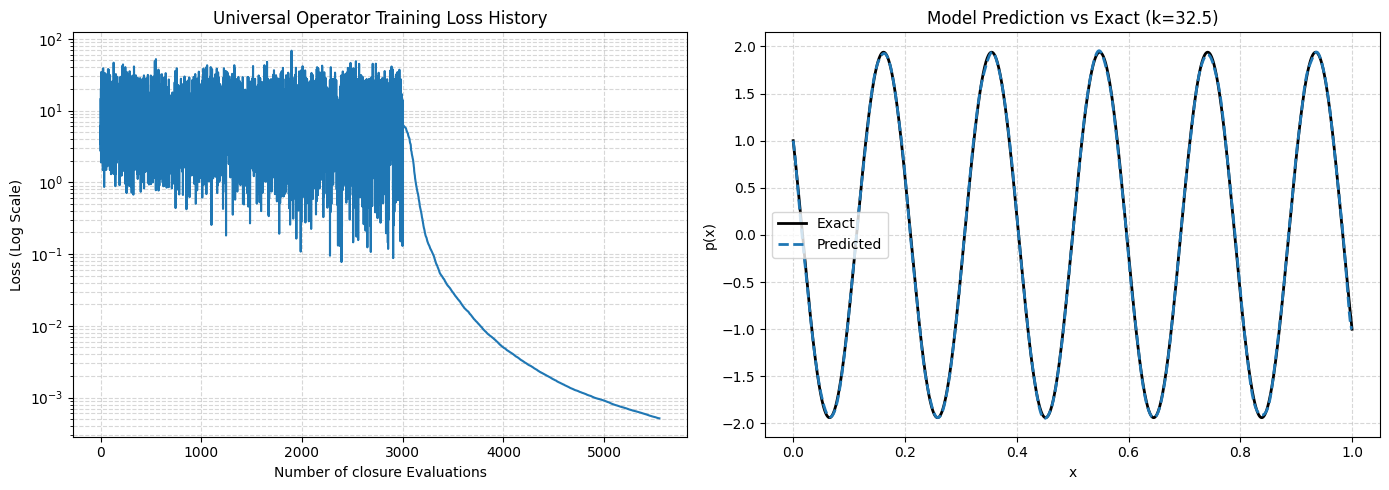

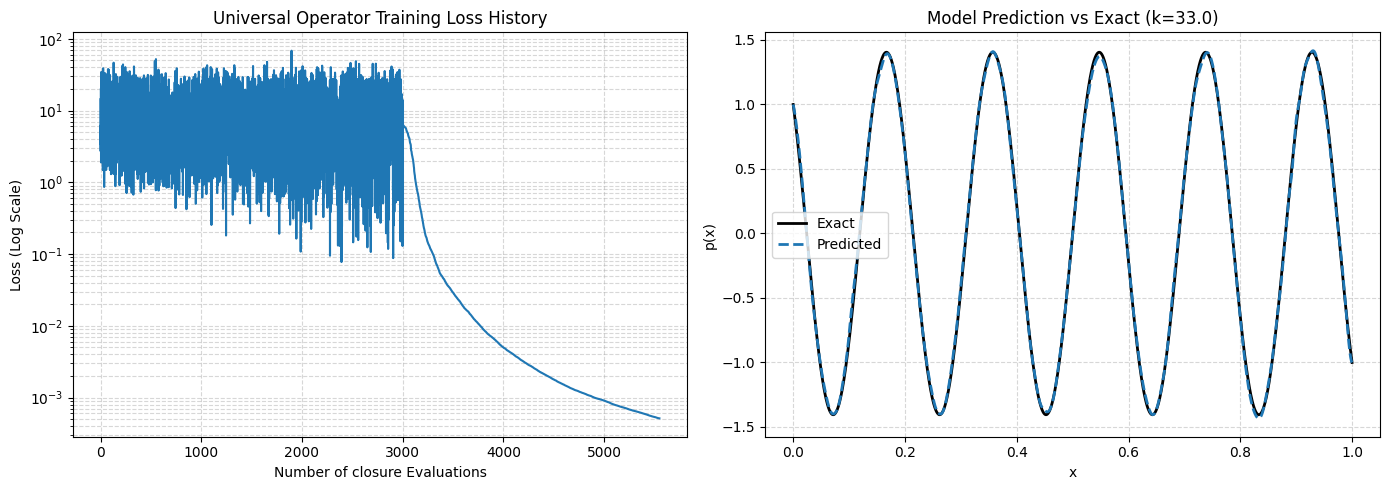

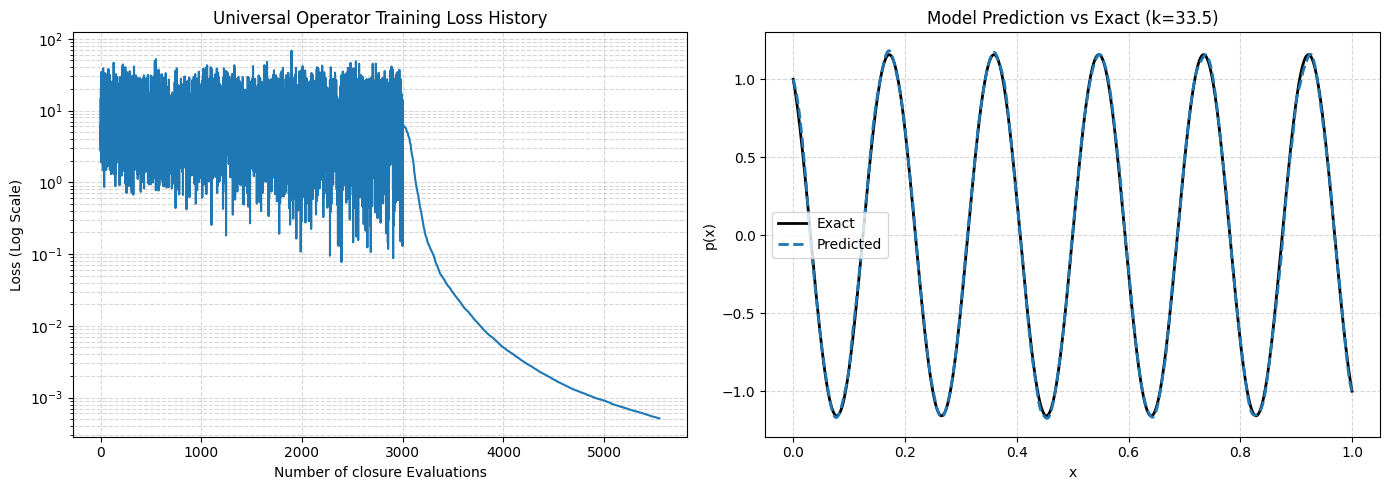

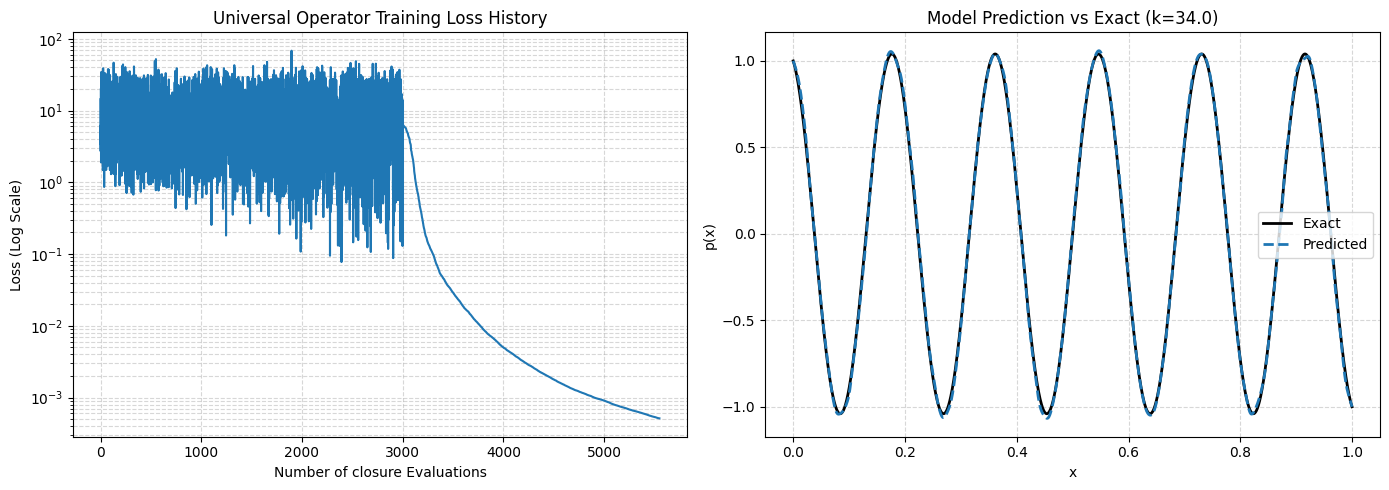

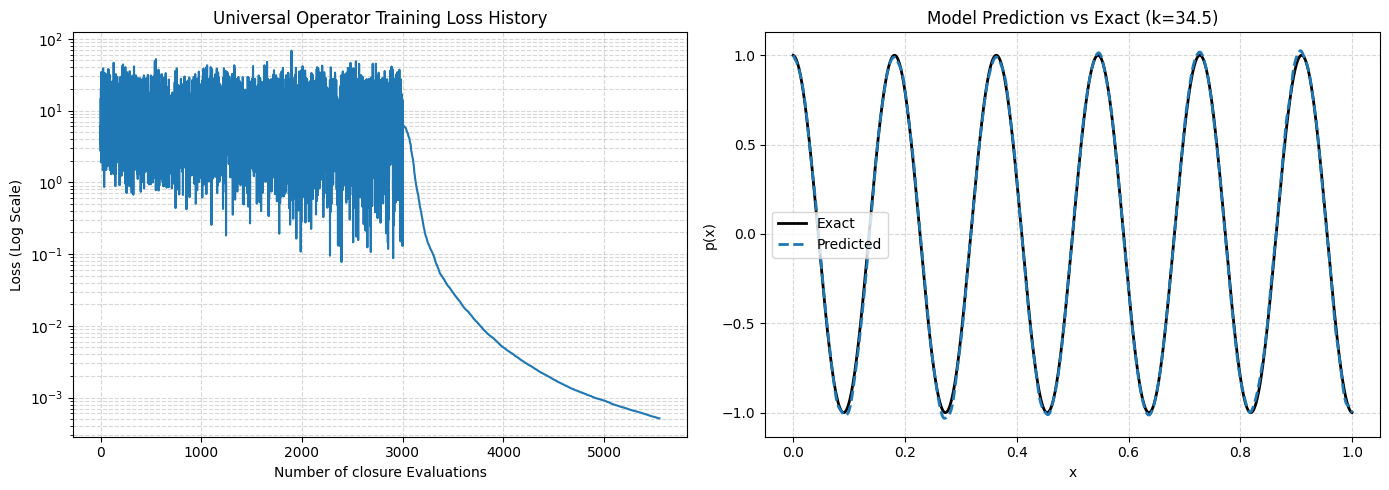

In [8]:
def exact_solution ( x, k ):
    if abs ( np.sin( k ) ) < 1e-6:
        return np.zeros_like ( x )
        
    c1 = 1.0
    c2 = - ( 1.0 + np.cos ( k ) ) / np.sin ( k )
    return c1 * np.cos ( k * x ) + c2 * np.sin ( k * x )

for k in np.arange ( 20, 35, 0.5 ):
    with torch.no_grad():
        x_plot = torch.linspace ( 0, 1, 2000, device = device ).view ( 1, -1, 1 )
        k_plot = torch.full_like ( x_plot, k )
        
        inputs = torch.cat ( [ x_plot, k_plot ], dim = -1 )
        pred_eval = model ( inputs ).cpu().numpy().flatten()
        
        x_eval = x_plot.cpu().numpy().flatten()
        exact_eval = exact_solution ( x_eval, k )

    fig, axs = plt.subplots ( 1, 2, figsize = (14, 5))

    axs[0].plot ( loss_history )
    axs[0].set_yscale ( "log" )
    axs[0].set_xlabel ( "Number of closure Evaluations" )
    axs[0].set_ylabel ( "Loss (Log Scale)" )
    axs[0].set_title ( f"Universal Operator Training Loss History" )
    axs[0].grid ( True, which = "both", linestyle="--", alpha = 0.5 )

    axs[1].plot ( x_eval, exact_eval, 'k-', linewidth = 2, label = "Exact" )
    axs[1].plot ( x_eval, pred_eval, '--', linewidth = 2, label = "Predicted" )
    axs[1].set_xlabel ( "x" )
    axs[1].set_ylabel ( "p(x)" )
    axs[1].set_title ( f"Model Prediction vs Exact (k={k})" )
    axs[1].grid ( True, linestyle = "--", alpha = 0.5 )
    axs[1].legend()

    plt.tight_layout()
    plt.show()